# MOVIE REVIEW SENTIMENT ANALYSIS

**BACKSTORY**

With the rapid growth of online movie platforms, thousands of users post reviews every day. Analyzing these reviews manually is time-consuming and impractical. This project uses Natural Language Processing (NLP) and Machine Learning to automatically identify whether a movie review expresses a positive or negative sentiment, enabling faster analysis of audience opinions.

**PROBLEM STATEMENT**

Develop a machine learning model that automatically predicts whether a movie review expresses a positive or negative sentiment using Natural Language Processing (NLP) techniques.

**BUSSINESS OBJECTIVE**

-Automatically classify movie reviews into Positive or Negative sentiments.

-Reduce the time and effort required for manual review analysis.

-Help movie platforms understand audience feedback and satisfaction.

-Enable production companies to identify strengths and weaknesses of movies based on customer opinions.

-Improve movie recommendation systems by incorporating user sentiment.

The goal is to predict a category (label) based on the text of a movie review.

Input (Features): Movie review text
Output (Target): Sentiment label

**FEATURE**

1) Review

2) Sentiment

**TARGET VARIABLE**  -- Sentiment

**DATASET**

-Dataset having the 500 rows and 2 columns.

-It is classification problem.

# IMPORTING LIBRARIES

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import re

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


**LOADING DATA**

In [76]:
df = pd.read_csv("C:\\Users\\tejas\\Downloads\\text_project_ml\\IMDB Dataset (1).csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**CHECKING DATA TYPES**

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     500 non-null    str  
 1   sentiment  500 non-null    str  
dtypes: str(2)
memory usage: 664.8 KB


**CHECKING SHAPES**

In [78]:
df.shape

(500, 2)

**CHECKING COLUMNS**

In [79]:
df.columns

Index(['review', 'sentiment'], dtype='str')

In [80]:
df.describe(include='all')

,review,sentiment
count,500,500
unique,500,2
top,One of the other reviewers has mentioned that ...,negative
freq,1,263


In [81]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [82]:
df.tail()

,review,sentiment
495,"""American Nightmare"" is officially tied, in my...",negative
496,"First off, I have to say that I loved the book...",negative
497,This movie was extremely boring. I only laughe...,negative
498,I was disgusted by this movie. No it wasn't be...,negative
499,Such a joyous world has been created for us in...,positive


In [83]:
df.describe(include='all')

,review,sentiment
count,500,500
unique,500,2
top,One of the other reviewers has mentioned that ...,negative
freq,1,263


In [85]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [86]:
df.duplicated().sum()

np.int64(0)

In [87]:
df.drop_duplicates(inplace=True)

In [88]:
df["sentiment"].value_counts()

sentiment
negative    263
positive    237
Name: count, dtype: int64

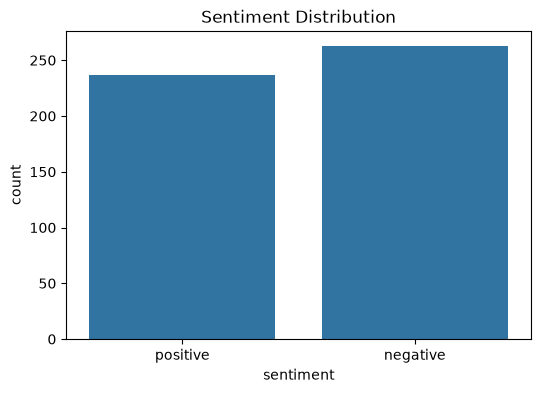

In [89]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

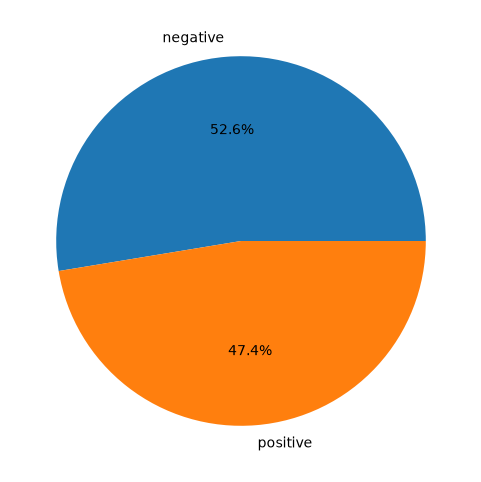

In [90]:
plt.figure(figsize=(6,6))

df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

In [91]:
df["review_length"] = df["review"].astype(str).apply(len)

df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,1725
1,A wonderful little production. The filming tec...,positive,962
2,I thought this was a wonderful way to spend ti...,positive,902
3,Basically there's a family where a little boy ...,negative,712
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1269


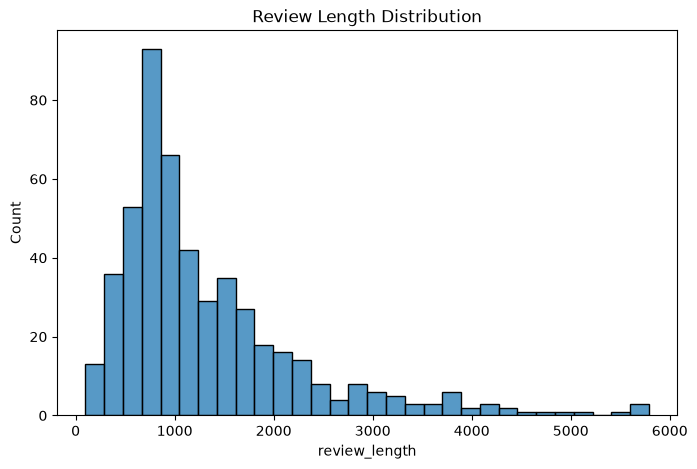

In [92]:
plt.figure(figsize=(8,5))

sns.histplot(df["review_length"], bins=30)

plt.title("Review Length Distribution")

plt.show()

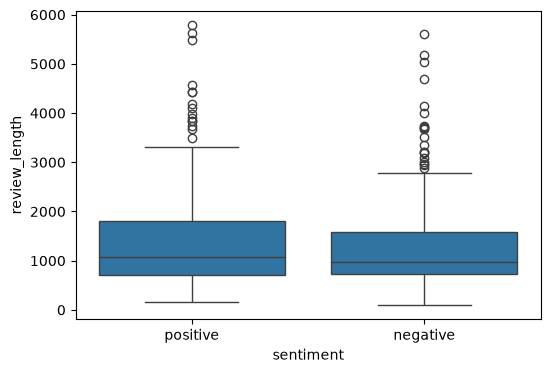

In [93]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="sentiment",
    y="review_length",
    data=df
)

plt.show()

In [136]:
stop_words = set(stopwords.words("english"))
stop_words



{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [137]:
lemmatizer = WordNetLemmatizer()
lemmatizer

<WordNetLemmatizer>

In [138]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [139]:
text

'one reviewer mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home many aryan muslim gangsta latino christian italian irish scuffle death stare dodgy dealing shady agreement never far away would say main appeal show due fact go show dare forget pretty picture painted mainstream audience forget charm forget romance oz mess around first episode ever saw struck nasty surreal say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard sold nickel inmate kill order get away well mannered middle class inmate turned prison bitch due lack street skill prison experience watching oz m

In [96]:
df["clean_review"] = df["review"].apply(clean_text)

In [97]:
df[["review","clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. The filming tec...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


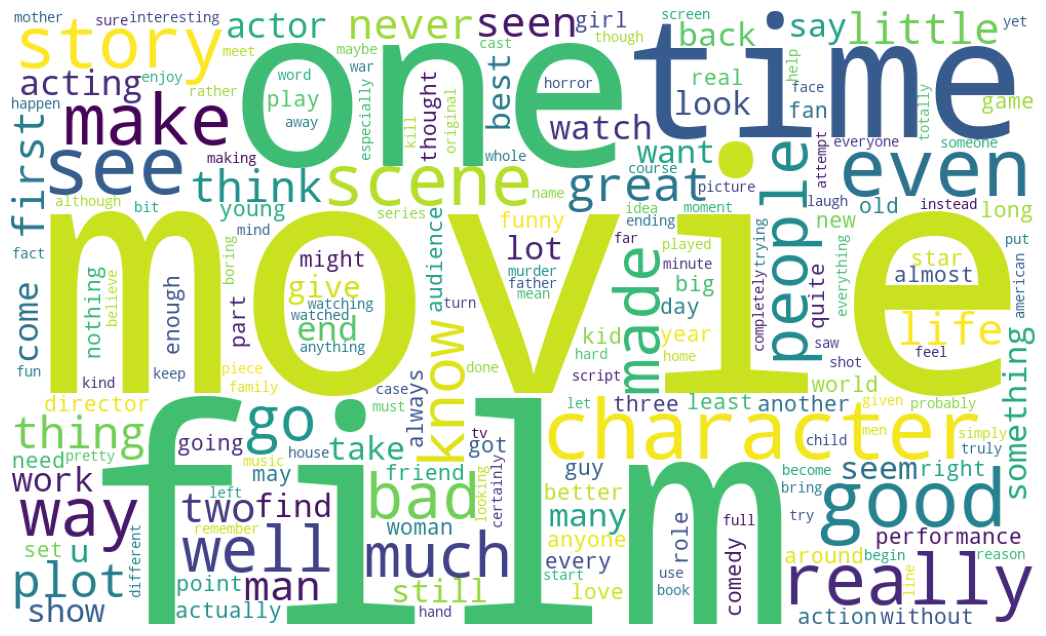

In [98]:
text = " ".join(df["clean_review"].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [107]:
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

print(df["sentiment"].unique())

<ArrowStringArray>
['1', '0']
Length: 2, dtype: str


In [108]:
df["sentiment"] = df["sentiment"].str.strip().str.lower()

df["sentiment"] = df["sentiment"].replace({
    "positive":1,
    "negative":0
})

df.head()

,review,sentiment,review_length,clean_review
0,One of the other reviewers has mentioned that ...,1,1725,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. The filming tec...,1,962,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,902,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,712,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1269,petter mattei love time money visually stunnin...


In [109]:
print(df["sentiment"].unique())
print(df["sentiment"].dtype)
print(df["sentiment"].isnull().sum())

<ArrowStringArray>
['1', '0']
Length: 2, dtype: str
str
0


In [110]:
df["sentiment"] = df["sentiment"].astype(int)

In [111]:
X = df["clean_review"]
y = df["sentiment"]

In [112]:
print(y.head())
print(y.unique())
print(y.dtype)

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64
[1 0]
int64


In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X)

In [100]:
df["sentiment"].value_counts()

sentiment
0    263
1    237
Name: count, dtype: int64

In [101]:
X = df["clean_review"]

y = df["sentiment"]

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X)

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [115]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(400, 5000)
(100, 5000)
(400,)
(100,)


In [116]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [117]:
pred_lr = lr.predict(X_test)

In [118]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred_lr)

0.76

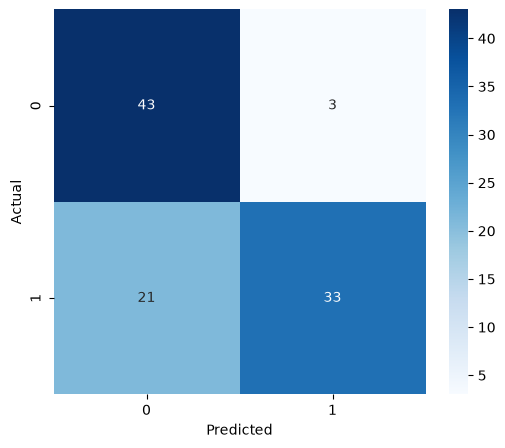

In [119]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_lr)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [120]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.67      0.93      0.78        46
           1       0.92      0.61      0.73        54

    accuracy                           0.76       100
   macro avg       0.79      0.77      0.76       100
weighted avg       0.80      0.76      0.76       100



In [121]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[217.,183.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.61,-0.78]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[0.2 ,0.05,0. ,...,1.92,0.37,0.1 ], [0.03,0.11,0.12,...,0.65,0.03,0.14]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-8.62,-8.75,-8.8 ,...,-7.73,-8.49,-8.71], [-8.74,-8.66,-8.66,...,-8.27,-8.73,-8.64]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [122]:
pred_nb = nb.predict(X_test)

In [123]:
accuracy_score(y_test, pred_nb)

0.63

In [124]:
print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

           0       0.56      0.98      0.71        46
           1       0.95      0.33      0.49        54

    accuracy                           0.63       100
   macro avg       0.75      0.66      0.60       100
weighted avg       0.77      0.63      0.59       100



In [125]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes"
    ],

    "Accuracy":[
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_nb)
    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.76
1,Naive Bayes,0.63


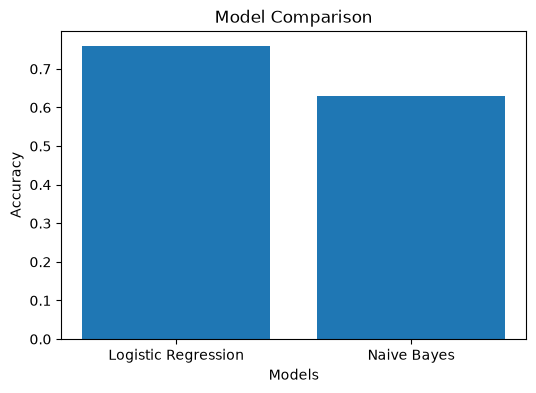

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

In [127]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.76
1,Naive Bayes,0.63


In [128]:
import pickle

pickle.dump(
    lr,
    open("logistic_sentiment_model.pkl","wb")
)

In [129]:
pickle.dump(
    tfidf,
    open("tfidf_vectorizer.pkl","wb")
)

In [130]:
model = pickle.load(
    open("logistic_sentiment_model.pkl","rb")
)

vectorizer = pickle.load(
    open("tfidf_vectorizer.pkl","rb")
)

In [131]:
review = [
    "The movie was fantastic and the acting was amazing."
]

review = vectorizer.transform(review)

prediction = model.predict(review)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Positive Review 😊


In [132]:
review = [
    "The movie was boring and a complete waste of time."
]

review = vectorizer.transform(review)

prediction = model.predict(review)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Negative Review 😞
